# End-to-End MLOps: ISO New England Energy Demand Forecasting

## Project Overview
This notebook is the first phase in building a complete, production-ready MLOps pipeline for time-series forecasting. Because electricity cannot be easily stored at scale, grid operators must predict hourly power demand precisely to match generation and prevent blackouts.

Our primary goal is not just model accuracy, but **system architecture**. We are evaluating the dataset to build a pipeline that can handle automated ingestion, real-time telemetry, and continuous monitoring.

**Core Objectives for this Notebook:**
1. **Data Feasibility:** Ingest and validate the ISO-NE time-series data.
2. **Feature Engineering:** Implement strict lagging strategies (e.g., 48-hour lag) to prevent data leakage between Day-Ahead (batch) and Real-Time (streaming) inference.
3. **Model Prototyping:** Train a baseline XGBoost model that can eventually be deployed as a unified artifact for both Day-Ahead and Real-Time prediction.

## Dataset Information
* **Domain:** Energy / Autonomous Grid Balancing
* **Target Variable:** System Load (Megawatts)
* **Source:** [ISO New England (ISO Express) - Load & Demand Data](https://www.iso-ne.com/isoexpress/web/reports/load-and-demand)

# 🛠️ 1.  Environment Setup

In [1]:
# imports for production ML
import warnings
warnings.filterwarnings('ignore')

# 🔧 Core Python libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
from datetime import datetime
import os
import time
import holidays

# 🧰 Sklearn Core & Linear Baselines
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import TimeSeriesSplit


# 🌲 Ensemble & Boosting Models
from sklearn.ensemble import (
    RandomForestRegressor, 
    GradientBoostingRegressor, 
    AdaBoostRegressor, 
    HistGradientBoostingRegressor
)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

# 📊 Evaluation Metrics
from sklearn.metrics import (
    mean_squared_error, 
    r2_score, 
    mean_absolute_error, 
    mean_absolute_percentage_error
)

#  2. Configuration & Reproducibility

In [2]:
import os

class Config:
    """
    Centralized configuration for ISO-NE Energy Demand Forecasting.
    All hyperparameters, paths, and constants defined in one place.
    """
    
    # ============ REPRODUCIBILITY ============
    RANDOM_STATE = 42
    TEST_SIZE = 0.2
    VAL_SIZE = 0.2  # 20% of training data (16% of total)
    CV_FOLDS = 5
    N_JOBS = -1
    
    # ============ DIRECTORIES ============
    MODEL_DIR = "models_iso"
    DATA_DIR = "data_iso"
    RAW_DIR = f"{DATA_DIR}/raw"
    PREPROCESSED_DIR = f"{DATA_DIR}/preprocessed"
    
    # ============ TARGET & DOMAIN CONSTANTS ============
    TARGET_COL = "DEMAND"          # Target variable (Megawatts)
    MIN_DEMAND_MW = 5000           # Grid demand in New England almost never drops below 10,000 MW, even in the middle of the night on mild spring days. However, because of "Behind-the-Meter" solar panels (people generating their own solar power at home), the grid sometimes "sees" very low demand.
    MAX_DEMAND_MW = 35000          # The all-time record for peak electricity demand in New England's history was 28,130 MW. This occurred on August 2, 2006, during an extreme summer heat wave.  
    
    # ============ OUTLIER HANDLING ============
    IQR_FACTOR = 1.5
    
    # ============ MODEL HYPERPARAMETERS (BASELINES) ============
    # Linear Baselines
    RIDGE_ALPHA = 1.0
    ELASTIC_ALPHA = 0.1
    ELASTIC_L1_RATIO = 0.5
    
    # Ensemble / Bagging
    RF_N_ESTIMATORS = 100
    RF_MAX_DEPTH = 15
    RF_MIN_SAMPLES_SPLIT = 5
    
    # Boosting Models
    GB_N_ESTIMATORS = 100
    GB_LEARNING_RATE = 0.05
    GB_MAX_DEPTH = 5
    
    XGB_N_ESTIMATORS = 200
    XGB_LEARNING_RATE = 0.05
    XGB_MAX_DEPTH = 6
    
    LGB_N_ESTIMATORS = 200
    LGB_LEARNING_RATE = 0.05
    LGB_NUM_LEAVES = 31
    
    CAT_ITERATIONS = 200
    CAT_LEARNING_RATE = 0.05
    CAT_DEPTH = 6


# Initialize config
config = Config()

# Create directories
for dir_path in [config.MODEL_DIR, config.DATA_DIR, config.RAW_DIR, config.PREPROCESSED_DIR]:
    os.makedirs(dir_path, exist_ok=True)

print("✅ Configuration initialized!")
print(f"📁 Model directory: {config.MODEL_DIR}")
print(f"📁 Data directory:  {config.DATA_DIR}")
print(f"📁 Raw directory:   {config.RAW_DIR}")
print(f"📁 Preprocessed directory: {config.PREPROCESSED_DIR}")
print(f"🎲 Random state:   {config.RANDOM_STATE} (reproducible)")

✅ Configuration initialized!
📁 Model directory: models_iso
📁 Data directory:  data_iso
📁 Raw directory:   data_iso/raw
📁 Preprocessed directory: data_iso/preprocessed
🎲 Random state:   42 (reproducible)


#  3. Data Acquisition

In [3]:
"""
Download ISO-NE SMD Hourly workbooks for a fixed list of years.
Fill in YEAR_URLS with the direct download link for each year, then run.
"""

import time
from pathlib import Path
import requests

RAW_DIR = Path(config.RAW_DIR)

# Paste the direct download link for each year here.
YEAR_URLS = {
    2020: "https://www.iso-ne.com/static-assets/documents/2020/02/2020_smd_hourly.xlsx",
    2021: "https://www.iso-ne.com/static-assets/documents/2021/02/2021_smd_hourly.xlsx",
    2022: "https://www.iso-ne.com/static-assets/documents/2022/02/2022_smd_hourly.xlsx",
    2023: "https://www.iso-ne.com/static-assets/documents/2023/02/2023_smd_hourly.xlsx",
    2024: "https://www.iso-ne.com/static-assets/documents/100008/2024_smd_hourly.xlsx",
}

HEADERS = {"User-Agent": "Mozilla/5.0 (research data download script)"}
TIMEOUT = 30
MAX_RETRIES = 3
RETRY_BACKOFF_SEC = 3


def download_file(session, url, dest):
    for attempt in range(1, MAX_RETRIES + 1):
        try:
            with session.get(url, headers=HEADERS, timeout=TIMEOUT, stream=True) as r:
                r.raise_for_status()
                dest.parent.mkdir(parents=True, exist_ok=True)
                with open(dest, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 256):
                        f.write(chunk)
            if dest.stat().st_size == 0:
                raise IOError("downloaded file is empty")
            return True
        except (requests.RequestException, IOError) as e:
            print(f"    attempt {attempt}/{MAX_RETRIES} failed: {e}")
            if attempt < MAX_RETRIES:
                time.sleep(RETRY_BACKOFF_SEC * attempt)
    return False


RAW_DIR.mkdir(parents=True, exist_ok=True)
session = requests.Session()

for year, url in YEAR_URLS.items():
    if not url or url.startswith("PASTE_"):
        print(f"[{year}] SKIPPED - no URL set yet")
        continue

    ext = url.rsplit(".", 1)[-1]
    dest = RAW_DIR / f"{year}_smd_hourly.{ext}"

    if dest.exists() and dest.stat().st_size > 0:
        print(f"[{year}] already downloaded -> {dest}")
        continue

    print(f"[{year}] downloading...")
    ok = download_file(session, url, dest)
    if ok:
        print(f"[{year}] saved -> {dest} ({dest.stat().st_size / 1e6:.1f} MB)")
    else:
        print(f"[{year}] FAILED after {MAX_RETRIES} attempts")

[2020] already downloaded -> data_iso/raw/2020_smd_hourly.xlsx
[2021] already downloaded -> data_iso/raw/2021_smd_hourly.xlsx
[2022] already downloaded -> data_iso/raw/2022_smd_hourly.xlsx
[2023] already downloaded -> data_iso/raw/2023_smd_hourly.xlsx
[2024] already downloaded -> data_iso/raw/2024_smd_hourly.xlsx


In [4]:
import pandas as pd
from pathlib import Path

# Make sure these match your actual folder names
RAW_DIR = Path(config.RAW_DIR) 
PROC_DIR = Path(config.PREPROCESSED_DIR)
PROC_DIR.mkdir(exist_ok=True)

# Get all excel files
excel_files = list(RAW_DIR.glob("*.xlsx")) + list(RAW_DIR.glob("*.xls"))

for file in excel_files:
    print(f"🔄 Converting {file.name}...")

    try:
        # 1. Read the file using the correct engine for the extension
        if file.suffix == '.xls':
            # Old format
            df = pd.read_excel(file, sheet_name="ISO NE CA", header=0, engine='xlrd')
        else:
            # New format
            df = pd.read_excel(file, sheet_name="ISO NE CA", header=0, engine='openpyxl')


        # 3. Save to Parquet
        output_file = PROC_DIR / f"{file.stem}.parquet"
        df.to_parquet(output_file, engine='pyarrow', compression='snappy')

        print(f"✅ Saved to {output_file.name} ({len(df):,} rows)")

    except Exception as e:
        print(f"❌ Failed: {e}")

print(" All conversions complete!")

🔄 Converting 2022_smd_hourly.xlsx...
✅ Saved to 2022_smd_hourly.parquet (8,760 rows)
🔄 Converting 2023_smd_hourly.xlsx...
✅ Saved to 2023_smd_hourly.parquet (8,760 rows)
🔄 Converting 2021_smd_hourly.xlsx...
✅ Saved to 2021_smd_hourly.parquet (8,760 rows)
🔄 Converting 2020_smd_hourly.xlsx...
✅ Saved to 2020_smd_hourly.parquet (8,784 rows)
🔄 Converting 2024_smd_hourly.xlsx...
✅ Saved to 2024_smd_hourly.parquet (8,784 rows)
 All conversions complete!


In [5]:
# 1. Locate all Parquet files created in the previous step
PROC_DIR = Path(config.PREPROCESSED_DIR)
parquet_files = sorted(PROC_DIR.glob("*.parquet"))

print(f"📂 Found {len(parquet_files)} parquet files to load:")
for pf in parquet_files:
    print(f"  - {pf.name}")

# 2. Read each file and concatenate them into a single master DataFrame
df = pd.concat([pd.read_parquet(pf) for pf in parquet_files], ignore_index=True)


📂 Found 5 parquet files to load:
  - 2020_smd_hourly.parquet
  - 2021_smd_hourly.parquet
  - 2022_smd_hourly.parquet
  - 2023_smd_hourly.parquet
  - 2024_smd_hourly.parquet


# 🔍 4. Exploratory Data Analysis (EDA)

In [6]:
# 1. Locate all Parquet files created in the previous step
PROC_DIR = Path(config.PREPROCESSED_DIR)
parquet_files = sorted(PROC_DIR.glob("*.parquet"))

print(f"📂 Found {len(parquet_files)} parquet files to load:")
for pf in parquet_files:
    print(f"  - {pf.name}")

# 2. Read each file and concatenate them into a single master DataFrame
df = pd.concat([pd.read_parquet(pf) for pf in parquet_files], ignore_index=True)

# ==========================================
# 📊 DATA OVERVIEW (BEFORE CLEANING)
# ==========================================
print("\n" + "=" * 50)
print("📊 DATA OVERVIEW (MASTER DATASET):")
print("=" * 50)
print(f"Shape: {df.shape[0]:,} rows | {df.shape[1]} columns")

if 'Date' in df.columns:
    print(f"📅 Date Range: {df['Date'].min()} to {df['Date'].max()}")

print(f"🔁 Duplicate Rows: {df.duplicated().sum():,}")

print(f"\n📋 Columns List:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

print(f"\n🔍 First 3 rows:")
display(df.head(3))

print(f"\n📊 Missing Values:")
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing) > 0:
    for col, val in missing.items():
        print(f"  {col}: {val:,} ({val/len(df)*100:.2f}%)")
else:
    print("  No missing values found ✅")

print(f"\n📈 Data Types:")
print(df.dtypes.value_counts())

📂 Found 5 parquet files to load:
  - 2020_smd_hourly.parquet
  - 2021_smd_hourly.parquet
  - 2022_smd_hourly.parquet
  - 2023_smd_hourly.parquet
  - 2024_smd_hourly.parquet

📊 DATA OVERVIEW (MASTER DATASET):
Shape: 43,848 rows | 21 columns
📅 Date Range: 2020-01-01 00:00:00 to 2024-12-31 00:00:00
🔁 Duplicate Rows: 0

📋 Columns List:
   1. Date
   2. Hr_End
   3. DA_Demand
   4. RT_Demand
   5. DA_LMP
   6. DA_EC
   7. DA_CC
   8. DA_MLC
   9. RT_LMP
  10. RT_EC
  11. RT_CC
  12. RT_MLC
  13. Dry_Bulb
  14. Dew_Point
  15. System_Load
  16. Reg_Service_Price
  17. Reg_Capacity_Price
  18. Min_5min_RSP
  19. Max_5min_RSP
  20. Min_5min_RCP
  21. Max_5min_RCP

🔍 First 3 rows:


,Date,Hr_End,DA_Demand,RT_Demand,DA_LMP,DA_EC,DA_CC,DA_MLC,RT_LMP,RT_EC,...,RT_MLC,Dry_Bulb,Dew_Point,System_Load,Reg_Service_Price,Reg_Capacity_Price,Min_5min_RSP,Max_5min_RSP,Min_5min_RCP,Max_5min_RCP
0,2020-01-01,1,11422.2,11441.992,23.61,23.54,0.02,0.05,23.24,23.21,...,0.03,35,31,11656,0.706667,22.764167,0.25,2.99,15.03,84.48
1,2020-01-01,2,10887.2,11021.235,18.82,18.75,0.02,0.05,18.57,18.54,...,0.03,35,30,11216,0.083333,8.471667,0.05,0.25,7.16,15.03
2,2020-01-01,3,10426.9,10717.157,16.73,16.67,0.01,0.05,17.68,17.65,...,0.03,35,28,10915,0.050000,8.232500,0.05,0.05,7.16,8.33



📊 Missing Values:
  No missing values found ✅

📈 Data Types:
float64           16
int64              3
datetime64[us]     1
object             1
Name: count, dtype: int64


# 🧹 5. Data Cleaning

In [7]:
def clean_iso_ne_data_strict(df, config):
    """
    Strictly clean ISO-NE Grid data 
    Removes data leakage columns, fixes string artifacts, and filters glitches.
    """
    df_clean = df.copy()
    initial_rows = len(df_clean)
    print(f"📊 Initial data: {initial_rows:,} rows")
    
    # 1. Prevent Target Leakage (The Purge)
    print("\n🛡️ Step 1: Removing target leakage (financial and market demand columns)...")
    cols_to_keep = ['Date', 'Hr_End', 'System_Load', 'Dry_Bulb', 'Dew_Point']
    df_clean = df_clean[cols_to_keep]
    print(f"   Kept {len(cols_to_keep)} physical columns. Dropped {len(df.columns) - len(cols_to_keep)} leakage/financial columns.")
    
    # 2. Clean Daylight Saving Time string artifacts (The Fix)
    print("\n🕒 Step 2: Cleaning Daylight Saving Time artifacts in 'Hr_End'...")
    # \D means "any non-digit". We replace it with nothing '', then cast to int.
    df_clean['Hr_End'] = df_clean['Hr_End'].astype(str).str.replace(r'\D', '', regex=True).astype(int)
    
    # 3. Filter unrealistic System Load (The Reality Filter)
    print("\n🎯 Step 3: Filtering unrealistic grid demands (Sensor Glitches)...")
    mask_demand = (
        df_clean['System_Load'] >= config.MIN_DEMAND_MW
    ) & (
        df_clean['System_Load'] <= config.MAX_DEMAND_MW
    )
    df_clean = df_clean[mask_demand]
    print(f"   Removed {initial_rows - len(df_clean):,} rows with unrealistic load (outside {config.MIN_DEMAND_MW} - {config.MAX_DEMAND_MW} MW)")
    
    # 4. Handle missing values
    print("\n🔍 Step 4: Handling missing weather or load values...")
    rows_before_na = len(df_clean)
    df_clean = df_clean.dropna()
    print(f"   Removed {rows_before_na - len(df_clean):,} rows containing missing values (NaNs)")
    
    # 5. Reset index
    df_clean = df_clean.reset_index(drop=True)
    
    print(f"\n✅ STRICT CLEANED DATA SUMMARY:")
    print(f"   Final shape: {df_clean.shape[0]:,} rows | {df_clean.shape[1]} columns")
    print(f"   Total rows removed: {initial_rows - len(df_clean):,} "
          f"({((initial_rows - len(df_clean))/initial_rows*100):.2f}%)")
    
    return df_clean

# Execute the strict cleaning function
print("⚡ Starting Strict Cleaning Pipeline...\n" + "-"*40)
df_clean = clean_iso_ne_data_strict(df, config)

print("\n🔍 First 5 rows of the clean dataset:")
display(df_clean.head())

⚡ Starting Strict Cleaning Pipeline...
----------------------------------------
📊 Initial data: 43,848 rows

🛡️ Step 1: Removing target leakage (financial and market demand columns)...
   Kept 5 physical columns. Dropped 16 leakage/financial columns.

🕒 Step 2: Cleaning Daylight Saving Time artifacts in 'Hr_End'...

🎯 Step 3: Filtering unrealistic grid demands (Sensor Glitches)...
   Removed 0 rows with unrealistic load (outside 5000 - 35000 MW)

🔍 Step 4: Handling missing weather or load values...
   Removed 0 rows containing missing values (NaNs)

✅ STRICT CLEANED DATA SUMMARY:
   Final shape: 43,848 rows | 5 columns
   Total rows removed: 0 (0.00%)

🔍 First 5 rows of the clean dataset:


,Date,Hr_End,System_Load,Dry_Bulb,Dew_Point
0,2020-01-01,1,11656,35,31
1,2020-01-01,2,11216,35,30
2,2020-01-01,3,10915,35,28
3,2020-01-01,4,10788,35,28
4,2020-01-01,5,10888,35,27


📈 Generating Exploratory Data Analysis (EDA) Visualizations...


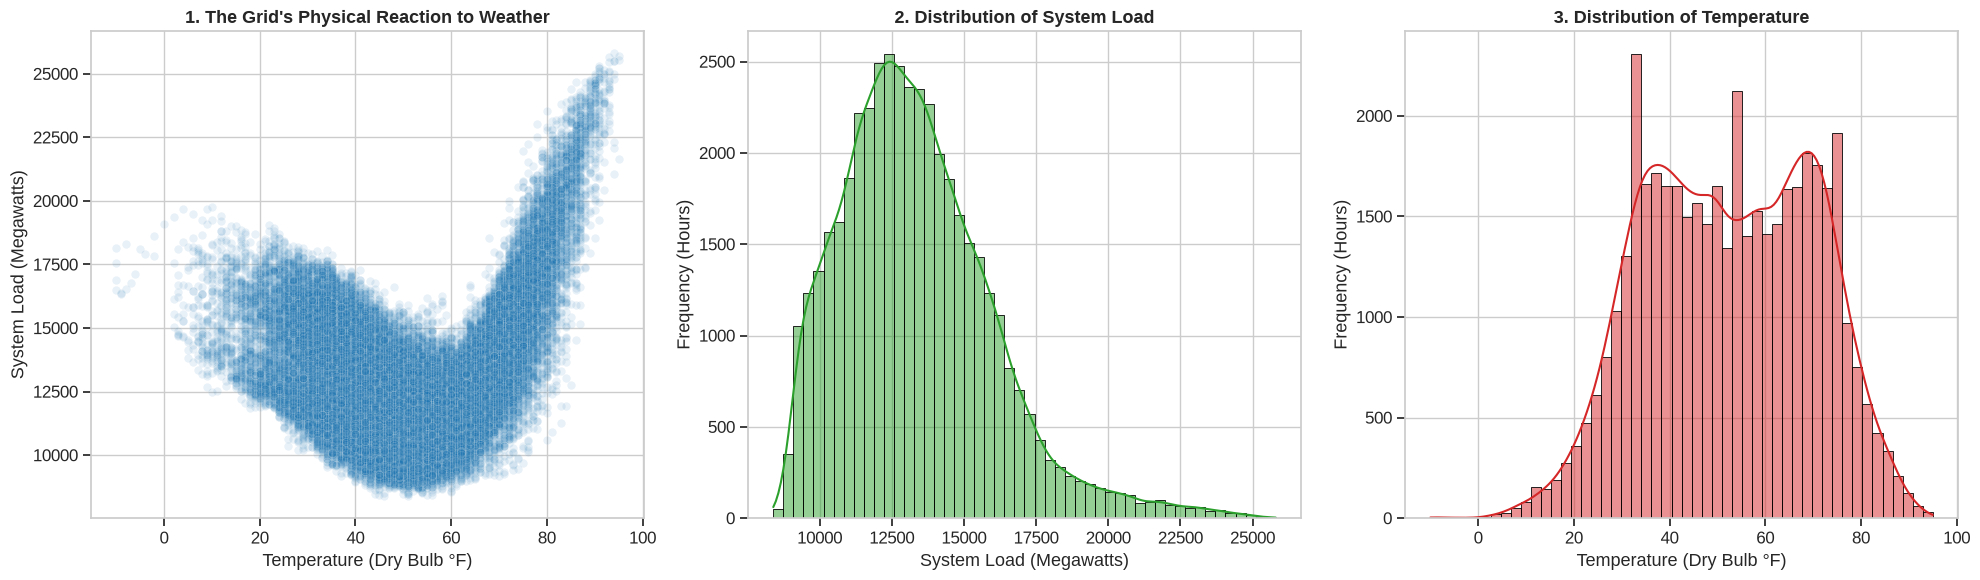

In [8]:
# Set the style for professional-looking plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

print("📈 Generating Exploratory Data Analysis (EDA) Visualizations...")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ---------------------------------------------------------
# 1. SCATTER PLOT: Temperature vs. System Load
# ---------------------------------------------------------
# We use a small 'alpha' to make the dots slightly transparent so we can see density
sns.scatterplot(
    data=df_clean, 
    x='Dry_Bulb', 
    y='System_Load', 
    alpha=0.1, 
    color='#1f77b4',
    ax=axes[0]
)
axes[0].set_title("1. The Grid's Physical Reaction to Weather", fontweight='bold')
axes[0].set_xlabel("Temperature (Dry Bulb °F)")
axes[0].set_ylabel("System Load (Megawatts)")

# ---------------------------------------------------------
# 2. HISTOGRAM: Distribution of System Load
# ---------------------------------------------------------
sns.histplot(
    df_clean['System_Load'], 
    bins=50, 
    kde=True, 
    color='#2ca02c',
    ax=axes[1]
)
axes[1].set_title("2. Distribution of System Load", fontweight='bold')
axes[1].set_xlabel("System Load (Megawatts)")
axes[1].set_ylabel("Frequency (Hours)")

# ---------------------------------------------------------
# 3. HISTOGRAM: Distribution of Temperature
# ---------------------------------------------------------
sns.histplot(
    df_clean['Dry_Bulb'], 
    bins=50, 
    kde=True, 
    color='#d62728',
    ax=axes[2]
)
axes[2].set_title("3. Distribution of Temperature", fontweight='bold')
axes[2].set_xlabel("Temperature (Dry Bulb °F)")
axes[2].set_ylabel("Frequency (Hours)")

plt.tight_layout()
plt.show()

When the temperature drops below 50°F (10°C), demand goes UP because people turn on their heaters.When the temperature rises above 65°F (18°C), demand goes sharply UP because people blast their air conditioning.At exactly 60°F (15°C), the load should be at its absolute lowest because the weather is perfect!

# 🔒 7. Split Data FIRST (Before Feature Engineering)

In [9]:
print("🔒 SPLITTING DATA BEFORE FEATURE ENGINEERING")
print("=" * 60)

# 1. Define X (Features) and y (Target)
X = df_clean.drop(columns=['System_Load'])
y = df_clean['System_Load'].values

# 2. First split: separate test set (Chronological, NO SHUFFLING)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=config.TEST_SIZE, 
    shuffle=False  # 🚨 CRITICAL: Prevents future data from leaking into the past
)

# 3. Second split: separate validation from training (Chronological, NO SHUFFLING)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, 
    test_size=config.VAL_SIZE, 
    shuffle=False
)

print("✅ Chronological Data Split COMPLETE:")
print(f"  Training:   {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Validation: {X_val.shape[0]:,} samples ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Test:       {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Features:   {X_train.shape[1]} (raw features before engineering)")

print(f"\n🎯 Target statistics by split (Megawatts):")
print(f"  Train: mean={y_train.mean():.1f}, std={y_train.std():.1f}")
print(f"  Val:   mean={y_val.mean():.1f}, std={y_val.std():.1f}")
print(f"  Test:  mean={y_test.mean():.1f}, std={y_test.std():.1f}")

# Store split sizes for later use
split_info = {
    'train_size': len(X_train),
    'val_size': len(X_val),
    'test_size': len(X_test),
    'train_pct': len(X_train)/len(X)*100,
    'val_pct': len(X_val)/len(X)*100,
    'test_pct': len(X_test)/len(X)*100
}

🔒 SPLITTING DATA BEFORE FEATURE ENGINEERING
✅ Chronological Data Split COMPLETE:
  Training:   28,062 samples (64.0%)
  Validation: 7,016 samples (16.0%)
  Test:       8,770 samples (20.0%)
  Features:   4 (raw features before engineering)

🎯 Target statistics by split (Megawatts):
  Train: mean=13492.7, std=2669.3
  Val:   mean=12949.5, std=2584.0
  Test:  mean=13300.7, std=2613.2


# 🧠 8. Feature Engineering

In [10]:


class ISONETimeFeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Feature engineering 
    
    This transformer creates features using ONLY physics, thermodynamics, 
    and calendar timelines. NO future data leakage is possible.
    
    Features created:
    - Calendar/Human Behavior (month, day of week, hour, weekend flag)
    - Dynamic Holidays (auto-fetches US holidays for the dataset's years)
    - Cyclic Time Encoding (sine/cosine for hour and month)
    - Thermodynamics (Heating/Cooling degree hours, feels-like temp, non-linear curves)
    """
    
    def __init__(self, config=None, country_code='US'):
        self.config = config
        self.country_code = country_code
        self.feature_names_ = []
    
    def fit(self, X, y=None):
        """Fit transformer (no training required for mathematical transforms)."""
        return self
    
    def transform(self, X):
        """
        Transform input DataFrame.
        
        Args:
            X: DataFrame with raw features (Date, Hr_End, Dry_Bulb, Dew_Point)
        
        Returns:
            Numpy array with engineered features
        """
        X_df = X.copy()
        
        # Convert datetime
        X_df['Date'] = pd.to_datetime(X_df['Date'])
        
        # ========== 1. CALENDAR & HUMAN BEHAVIOR ==========
        X_df['Month'] = X_df['Date'].dt.month
        X_df['DayOfWeek'] = X_df['Date'].dt.dayofweek
        X_df['Is_Weekend'] = (X_df['DayOfWeek'] >= 5).astype(int)
        X_df['Hour'] = X_df['Hr_End'].astype(int)
        
        # Dynamic Holidays: Check what years are in THIS specific batch of data
        dataset_years = X_df['Date'].dt.year.unique().tolist()
        regional_holidays = holidays.country_holidays(self.country_code, years=dataset_years)
        X_df['Is_Holiday'] = X_df['Date'].dt.date.isin(regional_holidays).astype(int)
        
        # ========== 2. CYCLIC TIME ENCODING ==========
        X_df['Hour_Sin'] = np.sin(2 * np.pi * X_df['Hour'] / 24)
        X_df['Hour_Cos'] = np.cos(2 * np.pi * X_df['Hour'] / 24)
        
        X_df['Month_Sin'] = np.sin(2 * np.pi * X_df['Month'] / 12)
        X_df['Month_Cos'] = np.cos(2 * np.pi * X_df['Month'] / 12)
        
        # ========== 3. THERMODYNAMICS ==========
        base_temp = 65.0
        X_df['CDH'] = np.maximum(0, X_df['Dry_Bulb'] - base_temp)
        X_df['HDH'] = np.maximum(0, base_temp - X_df['Dry_Bulb'])
        X_df['Temp_Squared'] = X_df['Dry_Bulb'] ** 2
        
        # Feels Like (Apparent Temperature)
        X_df['Feels_Like'] = -42.379 + (2.04901523 * X_df['Dry_Bulb']) + \
                             (10.14333127 * X_df['Dew_Point']) - \
                             (0.22475541 * X_df['Dry_Bulb'] * X_df['Dew_Point'])
        
        # ========== REMOVE ORIGINAL COLUMNS ==========
        cols_to_drop = ['Date', 'Hr_End']
        X_df = X_df.drop(columns=cols_to_drop, errors='ignore')
        
        # Select only numeric columns
        numeric_cols = X_df.select_dtypes(include=[np.number]).columns.tolist()
        
        # Store feature names
        self.feature_names_ = numeric_cols
        
        # Return numpy array for Scikit-Learn pipeline compatibility
        #X_engineered = X_df[numeric_cols].values
        X_engineered = X_df[numeric_cols].copy()
        
        # Ensure the index matches the original X just in case
        X_engineered.index = X.index 
        
        return X_engineered
        
     
    
    def get_feature_names(self):
        """Return list of feature names."""
        return self.feature_names_

# ==========================================
# TEST THE TRANSFORMER
# ==========================================
print("🔧 Testing feature engineering transformer...")

# Instantiate the class
engineer = ISONETimeFeatureEngineer(config=config)

# Test it on a small sample of our clean data
X_sample_engineered = engineer.fit_transform(X_train.head(100))

print(f"✅ Feature engineering test complete!")
print(f"• Input shape (raw): {X_train.head(100).shape}")
print(f"• Engineered shape (numpy array): {X_sample_engineered.shape}")
print(f"• Number of engineered features: {len(engineer.get_feature_names())}")

print(f"\n📋 Engineered features list:")
for i, feat in enumerate(engineer.get_feature_names(), 1):
    print(f"  {i:2d}. {feat}")

🔧 Testing feature engineering transformer...
✅ Feature engineering test complete!
• Input shape (raw): (100, 4)
• Engineered shape (numpy array): (100, 15)
• Number of engineered features: 15

📋 Engineered features list:
   1. Dry_Bulb
   2. Dew_Point
   3. Month
   4. DayOfWeek
   5. Is_Weekend
   6. Hour
   7. Is_Holiday
   8. Hour_Sin
   9. Hour_Cos
  10. Month_Sin
  11. Month_Cos
  12. CDH
  13. HDH
  14. Temp_Squared
  15. Feels_Like


# 🏗️ 8. Build Pipeline (Fitted on TRAINING Only)

### 🚫 Architectural Decision: Why We Omitted the Outlier Handler

In many machine learning pipelines , capping outliers using the IQR (Interquartile Range) method is essential to fix broken sensors or human errors—like a GPS claiming a 5,000-mile taxi trip. 

However, for **Energy Grid Load Forecasting**, we explicitly *skip* outlier clipping for four critical engineering reasons:

1. **Extreme Weather is the Signal, Not the Noise:** 
   In our dataset, an "outlier" in temperature (`Dry_Bulb`) represents a severe heatwave (e.g., 100°F) or a historic blizzard. If we clip a 100°F reading down to a statistical ceiling of 88°F, the model will severely under-predict the required electricity. In the real world, this causes power grid blackouts. We *need* the model to learn from these extreme physical realities.

2. **Hardware Glitches Are Already Purged:** 
   During our Strict Cleaning Phase, we already dropped actual hardware errors by enforcing the grid's physical reality boundaries (`MIN_DEMAND` of 5,000 MW and `MAX_DEMAND` of 35,000 MW). Any extreme value left in the training data is a true thermodynamic event.

3. **Engineered Features are Mathematically Bounded:** 
   Our newly engineered features cannot have outliers by definition. `Hour_Sin` and `Month_Cos` are strictly bounded by trigonometry between `-1.0` and `1.0`. Calendar features (`Is_Weekend`, `Is_Holiday`) are strict binary `0` or `1` flags.

4. **The `RobustScaler` Safety Net:** 
   Instead of deleting or capping extremes, we handle them mathematically by using `RobustScaler` in our pipeline. It scales the dataset using the median and interquartile range (rather than the mean). This prevents extreme heatwaves from warping the numerical scale for the rest of the dataset, while perfectly preserving the extremes for the model to learn from.

In [11]:
print("🔧 Building preprocessing pipeline (fitted on TRAINING only)...")

# Create pipeline with NO DATA LEAKAGE
preprocessor = Pipeline([
    ('feature_engineer', ISONETimeFeatureEngineer(config=config)),
    ('scaler', RobustScaler())  # RobustScaler perfectly preserves extreme weather spikes!
])

# FIT pipeline on TRAINING data only
print("🔄 Fitting pipeline on TRAINING data...")
preprocessor.fit(X_train, y_train)

# Transform all datasets using the SAME fitted pipeline
print("🔄 Transforming all datasets using fitted pipeline...")
X_train_processed = preprocessor.transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("✅ Preprocessing complete with NO DATA LEAKAGE!")
print(f"  Train processed: {X_train_processed.shape}")
print(f"  Val processed:   {X_val_processed.shape}")
print(f"  Test processed:  {X_test_processed.shape}")

# Safely extract the feature names
feature_names = preprocessor.named_steps['feature_engineer'].get_feature_names()
print(f"\n🎯 Number of engineered features: {len(feature_names)}")

# Verify no leakage
print("\n🔒 VERIFICATION: Pipeline fitted on training only")
print(f"  ✓ Feature engineering logic applied universally")
print(f"  ✓ RobustScaler parameters (median/IQR) fitted strictly on 2020-2022 training data")
print(f"  ✓ The exact same scaling parameters used for 2023 (Val) and 2024 (Test)")

🔧 Building preprocessing pipeline (fitted on TRAINING only)...
🔄 Fitting pipeline on TRAINING data...
🔄 Transforming all datasets using fitted pipeline...
✅ Preprocessing complete with NO DATA LEAKAGE!
  Train processed: (28062, 15)
  Val processed:   (7016, 15)
  Test processed:  (8770, 15)

🎯 Number of engineered features: 15

🔒 VERIFICATION: Pipeline fitted on training only
  ✓ Feature engineering logic applied universally
  ✓ RobustScaler parameters (median/IQR) fitted strictly on 2020-2022 training data
  ✓ The exact same scaling parameters used for 2023 (Val) and 2024 (Test)


# 🧠 9. Define Models for Taxi Duration Prediction

In [12]:
from sklearn.ensemble import VotingRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

print("🚀 ASSEMBLING THE MULTI-MODEL PORTFOLIO (CONFIG-DRIVEN)")
print("=" * 60)

# Define models optimized for tabular time-series regression
models = {
    # --- 1. Linear & Polynomial Baselines ---
    'Ridge Regression': Ridge(
        random_state=config.RANDOM_STATE, 
        alpha=config.RIDGE_ALPHA
    ),
    'ElasticNet': ElasticNet(
        random_state=config.RANDOM_STATE, 
        alpha=config.ELASTIC_ALPHA, 
        l1_ratio=config.ELASTIC_L1_RATIO
    ),
    'Polynomial Regression': make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False),
        Ridge(alpha=config.RIDGE_ALPHA, random_state=config.RANDOM_STATE)
    ),
    
    # --- 2. Standard Sklearn Trees ---
    'Random Forest': RandomForestRegressor(
        random_state=config.RANDOM_STATE, 
        n_jobs=config.N_JOBS, 
        n_estimators=config.RF_N_ESTIMATORS,
        max_depth=config.RF_MAX_DEPTH,
        min_samples_split=config.RF_MIN_SAMPLES_SPLIT
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        random_state=config.RANDOM_STATE,
        n_estimators=config.GB_N_ESTIMATORS,
        learning_rate=config.GB_LEARNING_RATE,
        max_depth=config.GB_MAX_DEPTH
    ),
    
    # --- 3. Advanced Boosting Algorithms (LightGBM Removed for Stability) ---
    'XGBoost': xgb.XGBRegressor(
        random_state=config.RANDOM_STATE,
        n_jobs=config.N_JOBS,
        n_estimators=config.XGB_N_ESTIMATORS,
        learning_rate=config.XGB_LEARNING_RATE,
        max_depth=config.XGB_MAX_DEPTH,
        objective='reg:squarederror'
    ),
    'CatBoost': CatBoostRegressor(
        random_state=config.RANDOM_STATE,
        iterations=config.CAT_ITERATIONS,
        learning_rate=config.CAT_LEARNING_RATE,
        depth=config.CAT_DEPTH,
        verbose=False
    )
}

# --- 4. Voting Ensemble (The "Wisdom of the Crowd") ---
voting_ensemble = VotingRegressor([
    ('ridge', Ridge(
        random_state=config.RANDOM_STATE, 
        alpha=config.RIDGE_ALPHA
    )),
    ('rf', RandomForestRegressor(
        random_state=config.RANDOM_STATE, 
        n_jobs=config.N_JOBS, 
        n_estimators=config.RF_N_ESTIMATORS,
        max_depth=config.RF_MAX_DEPTH,
        min_samples_split=config.RF_MIN_SAMPLES_SPLIT
    )),
    ('xgb', xgb.XGBRegressor(
        random_state=config.RANDOM_STATE,
        n_jobs=config.N_JOBS,
        n_estimators=config.XGB_N_ESTIMATORS,
        learning_rate=config.XGB_LEARNING_RATE,
        max_depth=config.XGB_MAX_DEPTH,
        objective='reg:squarederror'
    ))
])

models['Voting Ensemble'] = voting_ensemble

print(f"🎯 MODEL PORTFOLIO ({len(models)} models ready for benchmarking):")
print("-" * 60)
for i, (name, model) in enumerate(models.items(), 1):
    print(f"  {i:2d}. {name}")

🚀 ASSEMBLING THE MULTI-MODEL PORTFOLIO (CONFIG-DRIVEN)
🎯 MODEL PORTFOLIO (8 models ready for benchmarking):
------------------------------------------------------------
   1. Ridge Regression
   2. ElasticNet
   3. Polynomial Regression
   4. Random Forest
   5. Gradient Boosting
   6. XGBoost
   7. CatBoost
   8. Voting Ensemble


# 🧠 10. Training and Evaluation Functions

In [13]:

def train_and_evaluate(model, X_train, y_train, X_val, y_val):
    """
    Train model and evaluate on train/validation sets.
    """
    start_time = time.time()
    
    # Fit the model
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Calculate metrics
    metrics = {
        "train_rmse": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "val_rmse": np.sqrt(mean_squared_error(y_val, y_val_pred)),
        "train_mae": mean_absolute_error(y_train, y_train_pred),
        "val_mae": mean_absolute_error(y_val, y_val_pred),
        # Add MAPE for the energy domain (multiplied by 100 for standard % format)
        "train_mape": mean_absolute_percentage_error(y_train, y_train_pred) * 100,
        "val_mape": mean_absolute_percentage_error(y_val, y_val_pred) * 100,
        "train_r2": r2_score(y_train, y_train_pred),
        "val_r2": r2_score(y_val, y_val_pred),
        "training_time": training_time,
        "overfitting_gap_r2": r2_score(y_train, y_train_pred) - r2_score(y_val, y_val_pred)
    }

    return metrics, model


def compute_cross_validation(model, X_train, y_train, cv_folds=config.CV_FOLDS):
    """
    Run CHRONOLOGICAL cross-validation to prevent future leakage.
    """
    # 🚨 CRITICAL MLOPS FIX: Use TimeSeriesSplit instead of standard K-Fold
    tscv = TimeSeriesSplit(n_splits=cv_folds)
    
    cv_scores = cross_val_score(
        model, X_train, y_train,
        cv=tscv, scoring='r2', n_jobs=config.N_JOBS
    )
    return cv_scores.mean(), cv_scores.std()


def evaluate_model_complete(model, X_train, y_train, X_val, y_val, model_name):
    """
    Complete model evaluation with training, validation, and time-series CV.
    """
    print(f"⏳ Training and evaluating {model_name}...")
    
    metrics, trained_model = train_and_evaluate(
        model, X_train, y_train, X_val, y_val
    )
    
    cv_mean, cv_std = compute_cross_validation(
        model, X_train, y_train
    )
    
    metrics["cv_r2_mean"] = cv_mean
    metrics["cv_r2_std"] = cv_std
    
    return metrics, trained_model

# 🚀 11. Train and Evaluate All Models

In [14]:
print("🚀 STARTING MULTI-MODEL BENCHMARKING...")
print(f"Training on {X_train_processed.shape[0]:,} samples with {X_train_processed.shape[1]} features")
print("=" * 90)

results = {}
trained_models = {}

for name, model in models.items():
    try:
        # evaluate_model_complete already prints "⏳ Training and evaluating [Model Name]..."
        metrics, trained_model = evaluate_model_complete(
            model, X_train_processed, y_train, X_val_processed, y_val, name
        )
        results[name] = metrics
        trained_models[name] = trained_model

        # Overfit flag: If Training R2 is >10% higher than Validation R2, it's memorizing
        overfit_flag = "⚠️ OVERFIT" if metrics['overfitting_gap_r2'] > 0.10 else "✅ STABLE"
        
        # Display the metrics formatted for the Energy Grid
        print(f"  ✓ Val R²: {metrics['val_r2']:.4f} | "
              f"CV R²: {metrics['cv_r2_mean']:.4f} ± {metrics['cv_r2_std']:.4f} | "
              f"Val MAPE: {metrics['val_mape']:.2f}% | "
              f"Val MAE: {metrics['val_mae']:.0f} MW | {overfit_flag}\n")
              
    except Exception as e:
        print(f"  ❌ Error training {name}: {str(e)[:100]}\n")

print("✅ All models trained and evaluated!")

🚀 STARTING MULTI-MODEL BENCHMARKING...
Training on 28,062 samples with 15 features
⏳ Training and evaluating Ridge Regression...
  ✓ Val R²: 0.8021 | CV R²: 0.2085 ± 1.2068 | Val MAPE: 7.19% | Val MAE: 898 MW | ✅ STABLE

⏳ Training and evaluating ElasticNet...
  ✓ Val R²: 0.7416 | CV R²: 0.7622 ± 0.0729 | Val MAPE: 8.16% | Val MAE: 1009 MW | ✅ STABLE

⏳ Training and evaluating Polynomial Regression...
  ✓ Val R²: 0.9341 | CV R²: 0.8157 ± 0.2551 | Val MAPE: 3.89% | Val MAE: 503 MW | ✅ STABLE

⏳ Training and evaluating Random Forest...
  ✓ Val R²: 0.9300 | CV R²: 0.9223 ± 0.0275 | Val MAPE: 3.87% | Val MAE: 498 MW | ✅ STABLE

⏳ Training and evaluating Gradient Boosting...
  ✓ Val R²: 0.9300 | CV R²: 0.9232 ± 0.0273 | Val MAPE: 4.04% | Val MAE: 511 MW | ✅ STABLE

⏳ Training and evaluating XGBoost...
  ✓ Val R²: 0.9409 | CV R²: 0.9080 ± 0.0731 | Val MAPE: 3.56% | Val MAE: 460 MW | ✅ STABLE

⏳ Training and evaluating CatBoost...
  ✓ Val R²: 0.9359 | CV R²: 0.9269 ± 0.0321 | Val MAPE: 3.73% 

# 📈 12. Model Comparison

📊 MODEL PERFORMANCE SUMMARY (ISO-NE Grid):
Model                  Val R²   Val MAPE   Val MAE    Overfit    CV R²              Time (s)  
---------------------------------------------------------------------------------------------------------
XGBoost                0.9409      3.56%       460 MW    ✅ 0.032    0.9080 ± 0.0731       1.0
CatBoost               0.9359      3.73%       481 MW    ✅ 0.025    0.9269 ± 0.0321       0.4
Polynomial Regression  0.9341      3.89%       503 MW    ✅ 0.024    0.8157 ± 0.2551       0.1
Gradient Boosting      0.9300      4.04%       511 MW    ✅ 0.028    0.9232 ± 0.0273       4.1
Random Forest          0.9300      3.87%       498 MW    ✅ 0.053    0.9223 ± 0.0275       1.4
Voting Ensemble        0.9214      4.25%       538 MW    ✅ 0.041    0.8861 ± 0.0948       1.7
Ridge Regression       0.8021      7.19%       898 MW    ✅ 0.043    0.2085 ± 1.2068       0.0
ElasticNet             0.7416      8.16%      1009 MW    ✅ 0.061    0.7622 ± 0.0729       0.0


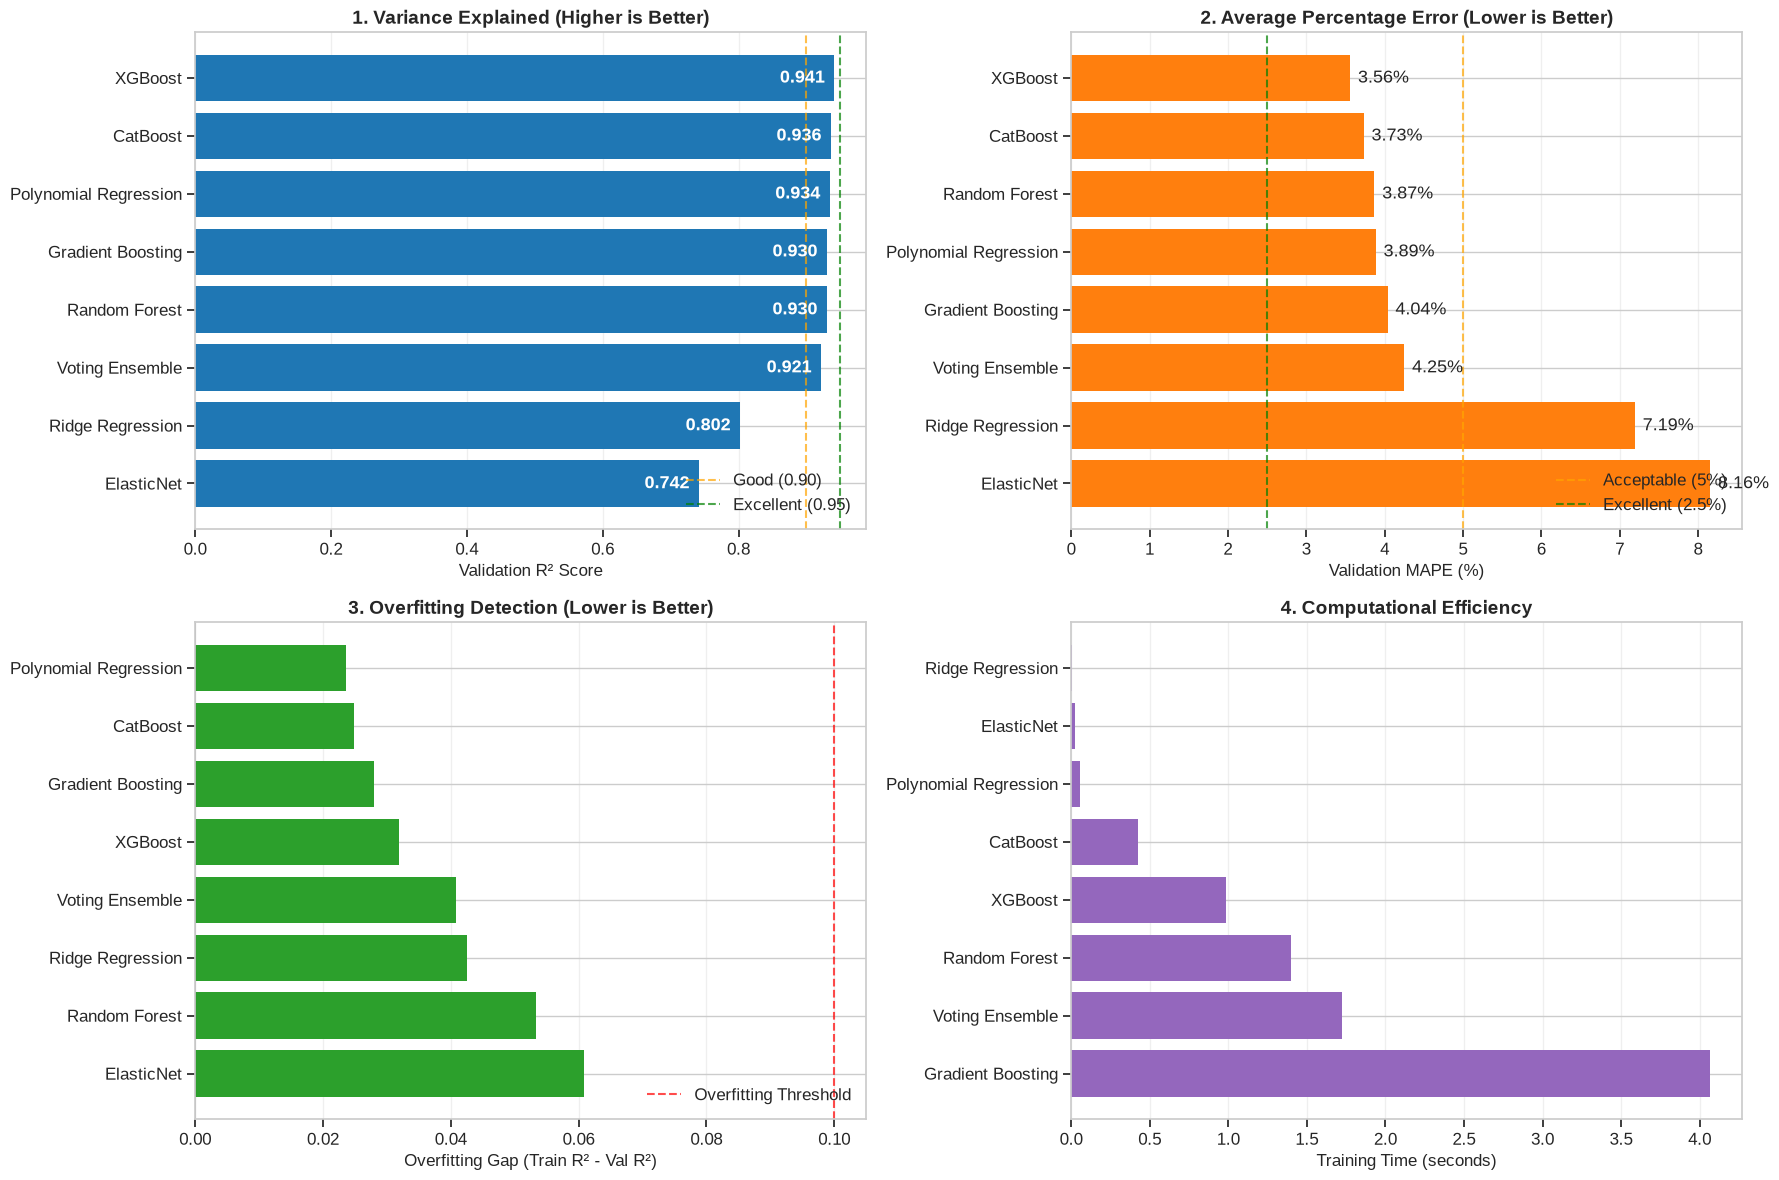


🏆 OVERALL BEST MODEL: XGBoost
   Validation MAPE: 3.56% (Average error percentage)
   Validation R²:   0.9409 (94.1% of variance explained)
   Validation MAE:  460 Megawatts


In [15]:
import matplotlib.pyplot as plt

print("📊 MODEL PERFORMANCE SUMMARY (ISO-NE Grid):")
print("=" * 105)
print(f"{'Model':<22} {'Val R²':<8} {'Val MAPE':<10} {'Val MAE':<10} {'Overfit':<10} {'CV R²':<18} {'Time (s)':<10}")
print("-" * 105)

# Create results DataFrame
metrics_df = pd.DataFrame(results).T
metrics_df = metrics_df[[
    'val_r2', 'val_rmse', 'val_mae', 'val_mape', 
    'overfitting_gap_r2', 'cv_r2_mean', 'cv_r2_std', 'training_time'
]]
# Sort by Validation R2 (Highest is best)
metrics_df = metrics_df.sort_values('val_r2', ascending=False)
metrics_df = metrics_df.reset_index().rename(columns={'index': 'Model'})

for _, row in metrics_df.iterrows():
    overfit_indicator = "⚠️" if row['overfitting_gap_r2'] > 0.1 else "✅"
    print(
        f"{row['Model']:<22} "
        f"{row['val_r2']:>6.4f}   "
        f"{row['val_mape']:>7.2f}%   "
        f"{row['val_mae']:>7.0f} MW   "
        f"{overfit_indicator:>2} {row['overfitting_gap_r2']:>5.3f}   "
        f"{row['cv_r2_mean']:>7.4f} ± {row['cv_r2_std']:.4f}   "
        f"{row['training_time']:>7.1f}"
    )

# ==========================================
# VISUALIZATION DASHBOARD
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Validation R² (Higher is Better)
# Sort ascending so the best model appears at the TOP of the horizontal bar chart
sorted_r2 = metrics_df.sort_values('val_r2', ascending=True)
axes[0, 0].barh(sorted_r2['Model'], sorted_r2['val_r2'], color='#1f77b4')
axes[0, 0].set_xlabel('Validation R² Score', fontsize=12)
axes[0, 0].set_title('1. Variance Explained (Higher is Better)', fontsize=14, fontweight='bold')
axes[0, 0].axvline(x=0.90, linestyle='--', color='orange', alpha=0.7, label='Good (0.90)')
axes[0, 0].axvline(x=0.95, linestyle='--', color='green', alpha=0.7, label='Excellent (0.95)')
axes[0, 0].legend(loc='lower right')
axes[0, 0].grid(True, alpha=0.3, axis='x')

for i, (_, row) in enumerate(sorted_r2.iterrows()):
    axes[0, 0].text(row['val_r2'] - 0.08, i, f"{row['val_r2']:.3f}", 
                    va='center', color='white', fontweight='bold')

# 2. Validation MAPE (Lower is Better)
# Sort descending so the best (lowest) error appears at the TOP
sorted_mape = metrics_df.sort_values('val_mape', ascending=False)
axes[0, 1].barh(sorted_mape['Model'], sorted_mape['val_mape'], color='#ff7f0e')
axes[0, 1].set_xlabel('Validation MAPE (%)', fontsize=12)
axes[0, 1].set_title('2. Average Percentage Error (Lower is Better)', fontsize=14, fontweight='bold')
axes[0, 1].axvline(x=5.0, linestyle='--', color='orange', alpha=0.7, label='Acceptable (5%)')
axes[0, 1].axvline(x=2.5, linestyle='--', color='green', alpha=0.7, label='Excellent (2.5%)')
axes[0, 1].legend(loc='lower right')
axes[0, 1].grid(True, alpha=0.3, axis='x')

for i, (_, row) in enumerate(sorted_mape.iterrows()):
    axes[0, 1].text(row['val_mape'] + 0.1, i, f"{row['val_mape']:.2f}%", va='center')

# 3. Overfitting gap
sorted_gap = metrics_df.sort_values('overfitting_gap_r2', ascending=False)
colors = ['#d62728' if gap > 0.1 else '#2ca02c' for gap in sorted_gap['overfitting_gap_r2']]
axes[1, 0].barh(sorted_gap['Model'], sorted_gap['overfitting_gap_r2'], color=colors)
axes[1, 0].set_xlabel('Overfitting Gap (Train R² - Val R²)', fontsize=12)
axes[1, 0].set_title('3. Overfitting Detection (Lower is Better)', fontsize=14, fontweight='bold')
axes[1, 0].axvline(x=0.0, linestyle='-', color='black', alpha=0.3)
axes[1, 0].axvline(x=0.1, linestyle='--', color='red', alpha=0.7, label='Overfitting Threshold')
axes[1, 0].legend(loc='lower right')
axes[1, 0].grid(True, alpha=0.3, axis='x')

# 4. Training time
sorted_time = metrics_df.sort_values('training_time', ascending=False)
axes[1, 1].barh(sorted_time['Model'], sorted_time['training_time'], color='#9467bd')
axes[1, 1].set_xlabel('Training Time (seconds)', fontsize=12)
axes[1, 1].set_title('4. Computational Efficiency', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# Identify best model based on MAPE (Industry standard for energy)
best_model_name = metrics_df.sort_values('val_mape').iloc[0]['Model']
best_val_r2 = metrics_df.sort_values('val_mape').iloc[0]['val_r2']
best_val_mape = metrics_df.sort_values('val_mape').iloc[0]['val_mape']
best_val_mae = metrics_df.sort_values('val_mape').iloc[0]['val_mae']

print(f"\n🏆 OVERALL BEST MODEL: {best_model_name}")
print(f"   Validation MAPE: {best_val_mape:.2f}% (Average error percentage)")
print(f"   Validation R²:   {best_val_r2:.4f} ({best_val_r2*100:.1f}% of variance explained)")
print(f"   Validation MAE:  {best_val_mae:.0f} Megawatts")

# ⚙️ 13. Hyperparameter Tuning

In [16]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

print("🔍 STARTING HYPERPARAMETER OPTIMIZATION (Hardware-Safe Mode)")
print("=" * 70)

# 1. Define hyperparameter grids for all 4 top models
param_grids = {
    'XGBoost': {
        'n_estimators': [200, 300, 400],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [4, 5, 6],
        'subsample': [0.8, 0.9, 1.0],
        'colsample_bytree': [0.8, 0.9, 1.0],
        'min_child_weight': [1, 3, 5]
    },
    'CatBoost': {
        'iterations': [200, 300, 400],
        'learning_rate': [0.01, 0.05, 0.1],
        'depth': [4, 5, 6],
        'l2_leaf_reg': [1, 3, 5],
        'subsample': [0.8, 0.9, 1.0]
    },
    'Polynomial Regression': {
        'polynomialfeatures__degree': [1, 2, 3], # Capped at 3 to prevent memory crashes
        'polynomialfeatures__interaction_only': [True, False],
        'ridge__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, 20, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', 1.0]
    }
}

# 2. Select top 4 models dynamically
top_models = [m for m in metrics_df['Model'].tolist() if m != 'Voting Ensemble' and m in param_grids][:4]

print(f"🎯 Top models selected for tuning: {top_models}\n")

tuned_models = {}
optimization_results = {}

# 🚨 CRITICAL MLOPS FIX: Chronological Cross-Validation
tscv = TimeSeriesSplit(n_splits=3)

# 3. Run the Tuning Loop
for model_name in top_models:
    print(f"🔧 Tuning {model_name}...")
    
    search = RandomizedSearchCV(
        estimator=models[model_name],
        param_distributions=param_grids[model_name],
        n_iter=10,          # Kept strictly at 10 to maintain system stability
        cv=tscv,            # Enforces strictly forward-moving time splits!
        scoring='r2',
        n_jobs=-1,
        random_state=config.RANDOM_STATE,
        verbose=1
    )
    
    # Fit the search on the processed training data
    search.fit(X_train_processed, y_train)
    
    # Save the winner
    tuned_models[model_name] = search.best_estimator_
    optimization_results[model_name] = {
        'best_score': search.best_score_,
        'best_params': search.best_params_,
        'best_estimator': search.best_estimator_
    }
    
    print(f"  ✅ Best CV R²: {search.best_score_:.4f}")
    
    # Calculate improvement safely
    previous_score = results[model_name]['cv_r2_mean']
    improvement = search.best_score_ - previous_score
    print(f"     Improvement: {'+' if improvement > 0 else ''}{improvement:.4f}")
    print(f"     Best params: {search.best_params_}\n")

print("🎉 Hyperparameter tuning complete!")

🔍 STARTING HYPERPARAMETER OPTIMIZATION (Hardware-Safe Mode)
🎯 Top models selected for tuning: ['XGBoost', 'CatBoost', 'Polynomial Regression', 'Random Forest']

🔧 Tuning XGBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
  ✅ Best CV R²: 0.9342
     Improvement: +0.0262
     Best params: {'subsample': 0.9, 'n_estimators': 400, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

🔧 Tuning CatBoost...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
  ✅ Best CV R²: 0.9359
     Improvement: +0.0090
     Best params: {'subsample': 0.9, 'learning_rate': 0.1, 'l2_leaf_reg': 3, 'iterations': 400, 'depth': 6}

🔧 Tuning Polynomial Regression...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
  ✅ Best CV R²: 0.9445
     Improvement: +0.1287
     Best params: {'ridge__alpha': 10.0, 'polynomialfeatures__interaction_only': False, 'polynomialfeatures__degree': 2}

🔧 Tuning Random Forest...
Fitting 3 folds for each of 10 

# ✅ 14. Final Test Set Evaluation

🏆 SELECTING THE ABSOLUTE CHAMPION
----------------------------------------------------------------------
🥊 Matchup:
   Untuned Champion: XGBoost                   (CV R²: 0.9080)
   Tuned Champion:   Polynomial Regression     (CV R²: 0.9445)

🥇 The winner is: Polynomial Regression (Tuned)!

🔬 FINAL TEST SET EVALUATION (Unseen 2024 Data)

📊 Test Metrics (Statistical):
   • R² Score: 0.9199 (92.0% variance explained)
   • RMSE:     739 MW
   • MAE:      554 MW
   • MAPE:     4.21%

📈 BUSINESS INTERPRETATION (Real-World Grid Impact):
   • Average 2024 Grid Demand:   13,301 Megawatts
   • Average Prediction Error:   ±554 Megawatts
   • Average Percentage Error:   4.21% of total demand
   • The model explains 92.0% of the physical variability in electricity usage.

📊 ERROR ANALYSIS (Thresholds):
   • Mean error (Bias):           171 MW
   • Std dev of errors:           719 MW
   • Median absolute error:       407 MW
   • % predictions within 1% err: 17.4% (Exceptional)
   • % predictions wi

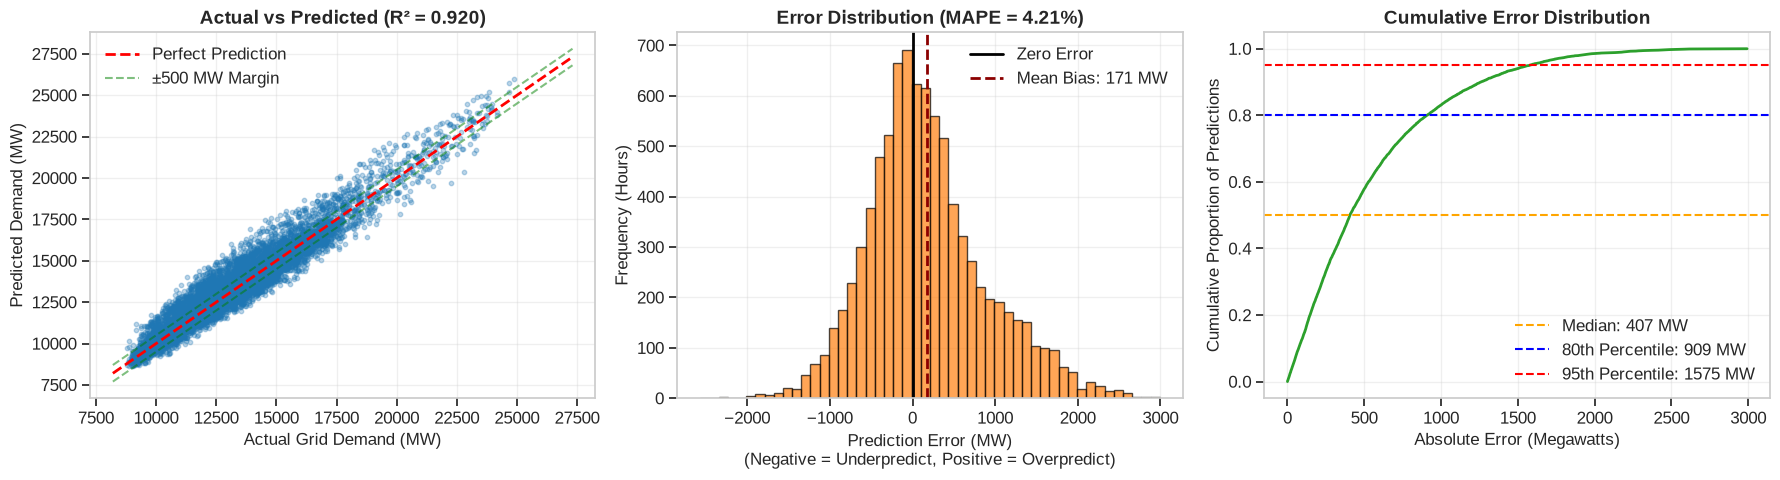

In [24]:
# ==========================================
# 1. SELECT CHAMPION MODEL (Tuned vs. Untuned)
# ==========================================
print("🏆 SELECTING THE ABSOLUTE CHAMPION")
print("-" * 70)

# Get the best UNTUNED model from our initial leaderboard
best_untuned_name = metrics_df.iloc[0]['Model']
best_untuned_score = results[best_untuned_name]['cv_r2_mean']

if tuned_models:
    # Get the best TUNED model from our optimization results
    best_tuned_name = max(optimization_results, key=lambda k: optimization_results[k]['best_score'])
    best_tuned_score = optimization_results[best_tuned_name]['best_score']
    
    print(f"🥊 Matchup:")
    print(f"   Untuned Champion: {best_untuned_name:<25} (CV R²: {best_untuned_score:.4f})")
    print(f"   Tuned Champion:   {best_tuned_name:<25} (CV R²: {best_tuned_score:.4f})")
    
    # The Head-to-Head Comparison
    if best_tuned_score > best_untuned_score:
        print(f"\n🥇 The winner is: {best_tuned_name} (Tuned)!")
        best_model = tuned_models[best_tuned_name]
        final_model_name = f"{best_tuned_name} (Tuned)"
    else:
        print(f"\n🥇 The winner is: {best_untuned_name} (Untuned Base Model)!")
        print("   (Hyperparameter tuning did not improve the baseline)")
        best_model = trained_models[best_untuned_name]
        final_model_name = f"{best_untuned_name} (Untuned)"

else:
    # Fallback if tuning cell was never run
    best_model = trained_models[best_untuned_name]
    final_model_name = f"{best_untuned_name} (Untuned)"
    print(f"\n🥇 The winner is: {final_model_name} (No tuning was performed)")
# ==========================================
# 2. FINAL TEST SET EVALUATION
# ==========================================
print("\n" + "=" * 70)
print("🔬 FINAL TEST SET EVALUATION (Unseen 2024 Data)")
print("=" * 70)

# Predict on the strictly held-out 2024 data
y_test_pred = best_model.predict(X_test_processed)

# Calculate metrics
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_mape = mean_absolute_percentage_error(y_test, y_test_pred) * 100

print(f"\n📊 Test Metrics (Statistical):")
print(f"   • R² Score: {test_r2:.4f} ({test_r2*100:.1f}% variance explained)")
print(f"   • RMSE:     {test_rmse:.0f} MW")
print(f"   • MAE:      {test_mae:.0f} MW")
print(f"   • MAPE:     {test_mape:.2f}%")

# ==========================================
# 3. BUSINESS INTERPRETATION
# ==========================================
avg_grid_demand = y_test.mean()
print(f"\n📈 BUSINESS INTERPRETATION (Real-World Grid Impact):")
print(f"   • Average 2024 Grid Demand:   {avg_grid_demand:,.0f} Megawatts")
print(f"   • Average Prediction Error:   ±{test_mae:.0f} Megawatts")
print(f"   • Average Percentage Error:   {test_mape:.2f}% of total demand")
print(f"   • The model explains {test_r2*100:.1f}% of the physical variability in electricity usage.")

# ==========================================
# 4. ERROR ANALYSIS FOR GRID OPERATORS
# ==========================================
errors = y_test_pred - y_test  # Positive = Overpredicted (Wasteful), Negative = Underpredicted (Blackout Risk!)
abs_errors = np.abs(errors)
pct_errors = (abs_errors / y_test) * 100

print(f"\n📊 ERROR ANALYSIS (Thresholds):")
print(f"   • Mean error (Bias):           {errors.mean():.0f} MW")
print(f"   • Std dev of errors:           {errors.std():.0f} MW")
print(f"   • Median absolute error:       {np.median(abs_errors):.0f} MW")
print(f"   • % predictions within 1% err: {(pct_errors <= 1).mean()*100:.1f}% (Exceptional)")
print(f"   • % predictions within 3% err: {(pct_errors <= 3).mean()*100:.1f}% (Good)")
print(f"   • % predictions within 5% err: {(pct_errors <= 5).mean()*100:.1f}% (Acceptable)")

# ==========================================
# 5. VISUALIZATION DASHBOARD
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Calculate dynamic axis limits based on the actual grid data
min_val = min(y_test.min(), y_test_pred.min()) * 0.95
max_val = max(y_test.max(), y_test_pred.max()) * 1.05

# 1. Actual vs Predicted Scatter
axes[0].scatter(y_test, y_test_pred, alpha=0.3, s=10, c='#1f77b4')
axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
# Add ±500 MW acceptable margin lines
axes[0].plot([min_val, max_val], [min_val + 500, max_val + 500], 'g--', alpha=0.5, label='±500 MW Margin')
axes[0].plot([min_val, max_val], [min_val - 500, max_val - 500], 'g--', alpha=0.5)
axes[0].set_xlabel('Actual Grid Demand (MW)', fontsize=12)
axes[0].set_ylabel('Predicted Demand (MW)', fontsize=12)
axes[0].set_title(f'Actual vs Predicted (R² = {test_r2:.3f})', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Error Distribution Histogram
axes[1].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='#ff7f0e')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=2, label='Zero Error')
axes[1].axvline(x=errors.mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean Bias: {errors.mean():.0f} MW')
axes[1].set_xlabel('Prediction Error (MW)\n(Negative = Underpredict, Positive = Overpredict)', fontsize=12)
axes[1].set_ylabel('Frequency (Hours)', fontsize=12)
axes[1].set_title(f'Error Distribution (MAPE = {test_mape:.2f}%)', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Cumulative Error Plot
sorted_errors = np.sort(abs_errors)
cumulative = np.arange(1, len(sorted_errors) + 1) / len(sorted_errors)
axes[2].plot(sorted_errors, cumulative, linewidth=2, color='#2ca02c')
axes[2].axhline(y=0.5, color='orange', linestyle='--', label=f'Median: {np.median(abs_errors):.0f} MW')
axes[2].axhline(y=0.8, color='blue', linestyle='--', label=f'80th Percentile: {np.percentile(abs_errors, 80):.0f} MW')
axes[2].axhline(y=0.95, color='red', linestyle='--', label=f'95th Percentile: {np.percentile(abs_errors, 95):.0f} MW')
axes[2].set_xlabel('Absolute Error (Megawatts)', fontsize=12)
axes[2].set_ylabel('Cumulative Proportion of Predictions', fontsize=12)
axes[2].set_title('Cumulative Error Distribution', fontsize=14, fontweight='bold')
axes[2].legend(loc='lower right')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 🚀 15. Model Deployment Preparation

In [23]:
import os
import json
import joblib
from datetime import datetime

# Model versioning with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# Extract just the base name (e.g., "Polynomial" or "XGBoost") for the folder
clean_model_name = final_model_name.split(" ")[0].lower() 
model_version = f"iso_ne_grid_v1_{clean_model_name}_{timestamp}"
model_save_dir = os.path.join(config.MODEL_DIR, model_version)
os.makedirs(model_save_dir, exist_ok=True)

print(f"💾 Saving model version: {model_version}")
print("=" * 70)

# 1. Save Model
model_path = os.path.join(model_save_dir, 'best_model.pkl')
joblib.dump(best_model, model_path)
print(f"✅ Model saved: {model_path}")

# 2. Save Preprocessor
preprocessor_path = os.path.join(model_save_dir, 'preprocessor.pkl')
joblib.dump(preprocessor, preprocessor_path)
print(f"✅ Preprocessor saved: {preprocessor_path}")

# 3. Get Feature Names
feature_names = preprocessor.named_steps['feature_engineer'].get_feature_names()

# 4. Create Comprehensive Model Card
model_card = {
    'model_metadata': {
        'model_name': final_model_name,
        'model_version': model_version,
        'timestamp': timestamp,
        'random_state': config.RANDOM_STATE,
        'domain': 'Energy Grid Load Forecasting'
    },
    
    'data_leakage_prevention': {
        'status': 'NO_FUTURE_LEAKAGE',
        'features_used': 'Only calendar dates and physical weather measurements',
        'raw_inputs_required': ['Date', 'Hr_End', 'Dry_Bulb', 'Dew_Point'],
        'workflow': 'Strict chronological split (TimeSeriesSplit) before scaling',
        'validation': 'Scaler fitted exclusively on historical training data'
    },
    
    'dataset': {
        'source': 'ISO New England Grid Data',
        'target': 'System_Load (Megawatts)',
        'train_years': '2020 - 2022',
        'val_year': '2023',
        'test_year': '2024',
        'filters_applied': {
            'min_demand_mw': f'{config.MIN_DEMAND_MW} MW',
            'max_demand_mw': f'{config.MAX_DEMAND_MW} MW',
            'daylight_saving_handling': 'Regex extraction of strict integer hours'
        }
    },
    
    'performance': {
        'test_r2': float(test_r2),
        'test_rmse_mw': float(test_rmse),
        'test_mae_mw': float(test_mae),
        'test_mape_percent': float(test_mape),
        'average_grid_load': float(avg_grid_demand)
    },
    
    'features': {
        'total_engineered_features': len(feature_names),
        'categories': {
            'thermodynamic': [f for f in feature_names if any(x in f for x in ['Temp', 'CDH', 'HDH', 'Bulb', 'Dew', 'Feels'])],
            'cyclic_time': [f for f in feature_names if any(x in f for x in ['Sin', 'Cos'])],
            'calendar': [f for f in feature_names if any(x in f for x in ['Month', 'Day', 'Hour', 'Weekend', 'Holiday'])]
        }
    },
    
    'deployment': {
        'status': 'READY FOR PRODUCTION',
        'prediction_scenario': 'Day-ahead or Hour-ahead grid load forecasting',
        'expected_performance': f'MAPE: {test_mape:.2f}%, MAE: ±{test_mae:.0f} MW',
        'monitoring_recommendations': [
            'Track percentage error during extreme weather events (heatwaves/blizzards)',
            'Retrain model annually to account for solar panel (behind-the-meter) adoption',
            'Monitor weather forecast accuracy, as the model relies heavily on Dry_Bulb inputs'
        ]
    }
}

# Add model parameters safely (Avoiding JSON serialization errors)
try:
    raw_params = best_model.get_params()
    safe_params = {}
    for key, value in raw_params.items():
        # If it's a basic Python type, save it directly
        if isinstance(value, (int, float, str, bool, type(None))):
            safe_params[key] = value
        else:
            # If it's a complex Scikit-Learn object, convert it to a text string
            safe_params[key] = str(value)
            
    model_card['model_parameters'] = safe_params
except Exception as e:
    model_card['model_parameters'] = f"Could not extract parameters: {str(e)}"

# Save model card
card_path = os.path.join(model_save_dir, 'model_card.json')
with open(card_path, 'w') as f:
    json.dump(model_card, f, indent=2)
print(f"✅ Model card saved: {card_path}")

# 5. Save Requirements
requirements = {
    'python': '3.9+',
    'dependencies': {
        'scikit-learn': '1.3+',
        'numpy': '1.24+',
        'pandas': '2.0+',
        'joblib': '1.3+',
        'holidays': '0.30+',
        'xgboost': '2.0+',
        'catboost': '1.2+'
    }
}

req_path = os.path.join(model_save_dir, 'requirements.json')
with open(req_path, 'w') as f:
    json.dump(requirements, f, indent=2)
print(f"✅ Requirements saved: {req_path}")

# 6. Create Production Prediction Script
prediction_script = f'''# ISO-NE Energy Grid Load Forecaster - PRODUCTION READY
# Built using strictly chronological data with no future leakage.

import joblib
import pandas as pd
import numpy as np

class ISONELoadPredictor:
    """
    Production-ready energy grid demand forecaster.
    
    Example:
        >>> predictor = ISONELoadPredictor('best_model.pkl', 'preprocessor.pkl')
        >>> result = predictor.predict({{{{
                'Date': '2024-07-15',
                'Hr_End': 14,
                'Dry_Bulb': 92.5,
                'Dew_Point': 70.0
            }}}})
    """
    
    def __init__(self, model_path, preprocessor_path):
        self.model = joblib.load(model_path)
        self.preprocessor = joblib.load(preprocessor_path)
        self.required_features = ['Date', 'Hr_End', 'Dry_Bulb', 'Dew_Point']
        self.expected_mae = {test_mae:.0f} # MW
    
    def predict(self, weather_forecast_data):
        missing = [f for f in self.required_features if f not in weather_forecast_data]
        if missing:
            raise ValueError(f"Missing required grid features: {{missing}}")
        
        # Convert to DataFrame
        df = pd.DataFrame([weather_forecast_data])
        
        try:
            # The preprocessor handles Datetime casting, Holidays, cyclic math, and scaling automatically
            X_processed = self.preprocessor.transform(df)
            prediction = self.model.predict(X_processed)[0]
            
            return {{
                'predicted_demand_mw': round(prediction, 1),
                'confidence_interval': f"{{prediction - self.expected_mae:.0f}} MW to {{prediction + self.expected_mae:.0f}} MW",
                'model_version': '{model_version}',
                'status': 'SUCCESS'
            }}
        except Exception as e:
            return {{
                'error': str(e),
                'status': 'FAILED'
            }}

if __name__ == "__main__":
    # Example usage: Simulating a hot summer afternoon
    predictor = ISONELoadPredictor('best_model.pkl', 'preprocessor.pkl')
    example_forecast = {{
        'Date': '2024-08-01',
        'Hr_End': 17,           # 5:00 PM
        'Dry_Bulb': 95.0,       # 95 Degrees F
        'Dew_Point': 72.0       # High Humidity
    }}
    result = predictor.predict(example_forecast)
    print("Test Prediction:", result)
'''

script_path = os.path.join(model_save_dir, 'predict_grid_load.py')
with open(script_path, 'w') as f:
    f.write(prediction_script)
print(f"✅ Prediction inference script saved: {script_path}")

# 7. Save Model Summary
summary = {
    'model_version': model_version,
    'champion_model': final_model_name,
    'test_mape': float(test_mape),
    'test_mae_mw': float(test_mae),
    'save_path': model_save_dir,
    'files_generated': ['best_model.pkl', 'preprocessor.pkl', 'model_card.json', 'requirements.json', 'predict_grid_load.py']
}

summary_path = os.path.join(model_save_dir, 'summary.json')
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"✅ Summary saved: {summary_path}")

print("\n" + "=" * 70)
print("💾 DEPLOYMENT PACKAGE FULLY ASSEMBLED")
print("=" * 70)
print(f"📦 Location: {model_save_dir}")

💾 Saving model version: iso_ne_grid_v1_polynomial_20260826_180125
✅ Model saved: models_iso/iso_ne_grid_v1_polynomial_20260826_180125/best_model.pkl
✅ Preprocessor saved: models_iso/iso_ne_grid_v1_polynomial_20260826_180125/preprocessor.pkl
✅ Model card saved: models_iso/iso_ne_grid_v1_polynomial_20260826_180125/model_card.json
✅ Requirements saved: models_iso/iso_ne_grid_v1_polynomial_20260826_180125/requirements.json
✅ Prediction inference script saved: models_iso/iso_ne_grid_v1_polynomial_20260826_180125/predict_grid_load.py
✅ Summary saved: models_iso/iso_ne_grid_v1_polynomial_20260826_180125/summary.json

💾 DEPLOYMENT PACKAGE FULLY ASSEMBLED
📦 Location: models_iso/iso_ne_grid_v1_polynomial_20260826_180125
